## KMeans & Elbow

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

## create dataset

X, y=make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.2,
    random_state=42
)


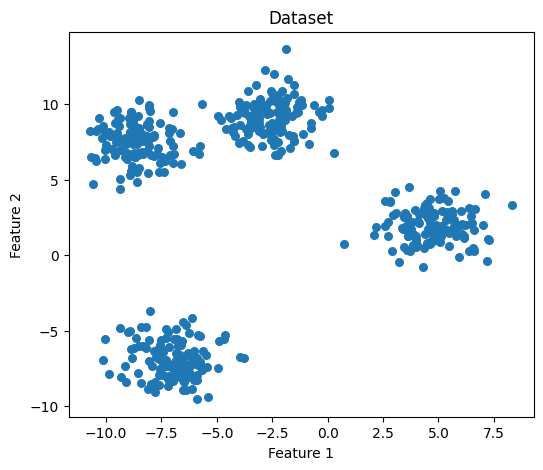

In [2]:
## Visualize dataset
plt.figure(figsize=(6, 5))
plt.scatter(
    X[:,0],
    X[:, 1],
    s=30
)
plt.title("Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

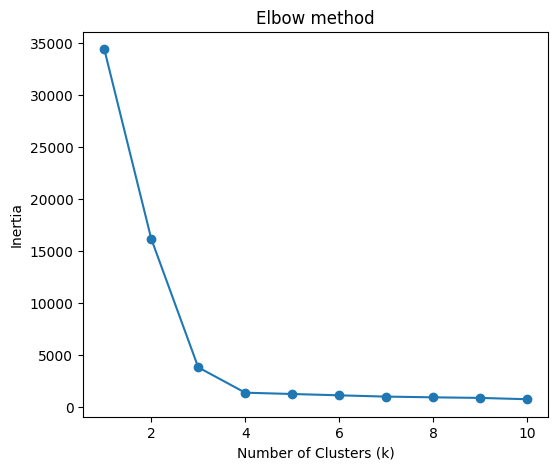

In [3]:
## Elbow method
inertias=[]
k_values=range(1, 11)

for k in k_values:
    kmeans=KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    
# plot elbow curve
plt.figure(figsize=(6, 5))

plt.plot(
    k_values,
    inertias,
    marker='o'
)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title("Elbow method")
plt.show()



k=2, Silhoutte Score=0.5836
k=3, Silhoutte Score=0.7404
k=4, Silhoutte Score=0.7483
k=5, Silhoutte Score=0.6554
k=6, Silhoutte Score=0.5354
k=7, Silhoutte Score=0.4638
k=8, Silhoutte Score=0.4276
k=9, Silhoutte Score=0.4059
k=10, Silhoutte Score=0.3446


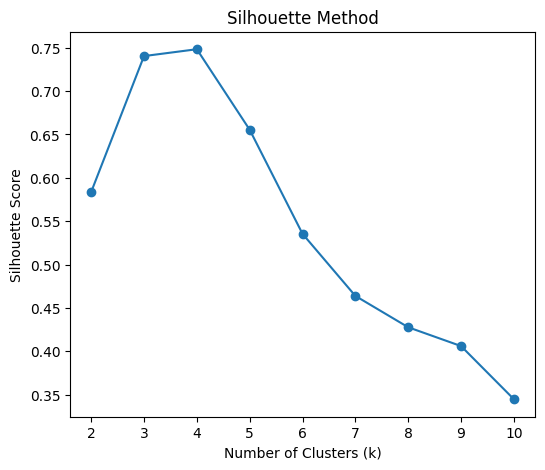

In [5]:
# Silhoutte method
silhouette_scores=[]

k_values=range(2, 11)

for k in k_values:
    kmeans=KMeans(
        n_clusters=k,
        random_state=42
    )
    
    labels=kmeans.fit_predict(X)
    score=silhouette_score(X, labels)
    silhouette_scores.append(score)
    
    print(f"k={k}, Silhoutte Score={score:.4f}")
    
plt.figure(figsize=(6, 5))
plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")

plt.show()

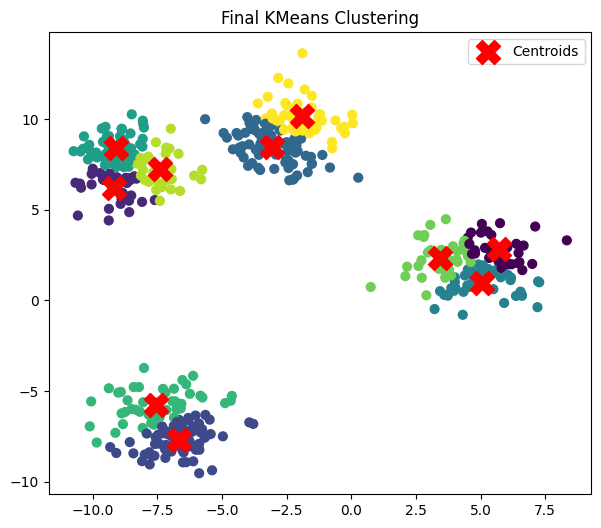

In [6]:
plt.figure(figsize=(7,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=kmeans.labels_,
    cmap='viridis',
    s=40
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c='red',
    marker='X',
    s=300,
    label='Centroids'
)

plt.legend()
plt.title("Final KMeans Clustering")

plt.show()